# Krylov Subspace Methods

## Motivation

Direct methods (LU, QR, Cholesky) require $O(n^3)$ work and $O(n^2)$ storage — infeasible for the large sparse systems arising in PDEs, graph problems, and machine learning (e.g., $n \sim 10^6$). **Krylov methods** instead build a sequence of low-dimensional subspaces and extract approximate solutions from them, often converging in far fewer than $n$ steps.

| Method | Problem | Matrix requirement |
|--------|---------|--------------------|
| **Conjugate Gradient (CG)** | $Ax = b$ | Symmetric positive definite |
| **MINRES** | $Ax = b$ | Symmetric (indefinite OK) |
| **GMRES** | $Ax = b$ | General square |
| **Lanczos** | Eigenvalues | Symmetric |
| **Arnoldi** | Eigenvalues | General |
| **LOBPCG** | $k$ smallest eigenvalues | Symmetric PD |

## The Core Idea

The **Krylov subspace** of order $m$ generated by $A$ and $b$ is:
$$\mathcal{K}_m(A, b) = \mathrm{span}\{b, Ab, A^2b, \ldots, A^{m-1}b\}$$

At step $m$, a Krylov method finds the best solution in $\mathcal{K}_m$ (under some optimality criterion). Since $\dim \mathcal{K}_m \leq n$, at most $n$ steps are needed — but in practice convergence is much faster.

## Prerequisites

| Topic | Key Concepts |
|-------|-------------|
| Spectral theorem | Eigendecomposition, symmetric matrices |
| Gram-Schmidt | Orthogonalization, QR factorization |
| Perturbation theory | Spectral gaps, condition numbers |
| Chebyshev polynomials | Optimal polynomial approximation |

## References

- Trefethen & Bau, *Numerical Linear Algebra* — Chapters 33–40 (definitive pedagogical source)
- Saad, *Iterative Methods for Sparse Linear Systems* (2nd ed., SIAM, 2003) — free online
- Golub & Van Loan, *Matrix Computations* — Chapter 10

In [1]:
%matplotlib inline
import numpy as np
from scipy import linalg as la
from scipy.sparse import diags as sp_diags
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Tolerances ─────────────────────────────────────────────────────────────────
ATOL = 1e-10

# ── Plot Style ─────────────────────────────────────────────────────────────────
PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'mediumpurple'
GRAY      = '#888888'

plt.rcParams.update({
    'figure.figsize'  : (12, 5),
    'font.size'       : 12,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'lines.linewidth' : 2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

def check(condition, label):
    status = 'PASS' if condition else 'FAIL'
    print(f'  [{status}]  {label}')
    return condition

# ── Matrix constructors ────────────────────────────────────────────────────────
def make_spd(n, kappa=10.0, rng=rng):
    """Symmetric positive definite matrix with controlled condition number."""
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    lams = np.geomspace(1.0, kappa, n)
    return Q @ np.diag(lams) @ Q.T

def laplacian_1d(n):
    """Tridiagonal 1D Laplacian: -1, 2, -1 (SPD)."""
    return (np.diag(2 * np.ones(n))
            - np.diag(np.ones(n - 1), 1)
            - np.diag(np.ones(n - 1), -1))

print('Setup complete.')

Setup complete.


---
## 1.  The Krylov Subspace

### 1.1  Definition

The **Krylov subspace** of order $m$ is:
$$\mathcal{K}_m(A, r) = \mathrm{span}\{r, Ar, A^2r, \ldots, A^{m-1}r\}$$

Starting from a residual $r = b - Ax_0$, Krylov methods search for the best correction $p \in \mathcal{K}_m(A,r)$ to the initial guess $x_0$.

### 1.2  Polynomial Viewpoint

Any vector in $\mathcal{K}_m(A, r)$ can be written as $p_{m-1}(A)r$ for some polynomial $p_{m-1}$ of degree $\leq m-1$. So Krylov methods are equivalent to **polynomial approximation** in the matrix argument.

For solving $Ax = b$, the optimal correction satisfies $x_m = x_0 + p_{m-1}(A)r_0$ and the error can be bounded using properties of $p_{m-1}$ on the spectrum of $A$.

### 1.3  Dimension

The sequence $\mathcal{K}_1 \subset \mathcal{K}_2 \subset \cdots$ is non-decreasing. It reaches its maximum dimension (the **degree of the minimal polynomial** of $A$ with respect to $r$) in at most $n$ steps, at which point the exact solution is contained in the subspace.

In [2]:
# ── Krylov Subspace: Construction & Properties ────────────────────────────────

def krylov_basis_raw(A, r, m):
    """Build raw (non-orthogonalized) Krylov basis: [r, Ar, A^2 r, ..., A^{m-1} r].

    Args:
        A: Square matrix.            Shape: (n, n)
        r: Starting vector.          Shape: (n,)
        m: Subspace dimension.

    Returns:
        K: Krylov basis columns.     Shape: (n, m)
    """
    n = len(r)
    K = np.zeros((n, m))
    K[:, 0] = r
    for j in range(1, m):
        K[:, j] = A @ K[:, j - 1]
    return K


def krylov_subspace_dim(A, r, tol=1e-12):
    """Find actual dimension of Krylov subspace (degree of minimal polynomial wrt r)."""
    n = len(r)
    K = np.zeros((n, n))
    K[:, 0] = r / np.linalg.norm(r)
    dim = 1
    for j in range(1, n):
        v = A @ K[:, j - 1]
        # Orthogonalize against previous
        for i in range(j):
            v -= np.dot(v, K[:, i]) * K[:, i]
        nv = np.linalg.norm(v)
        if nv < tol:
            break
        K[:, j] = v / nv
        dim += 1
    return dim


# ── Demo ───────────────────────────────────────────────────────────────────────
n = 8
A_demo = make_spd(n, kappa=20.0)
r_demo = rng.standard_normal(n)

print('Krylov subspace properties:')

# Subspace grows until it saturates
for m in [1, 2, 4, 6, 8]:
    K_raw = krylov_basis_raw(A_demo, r_demo, m)
    rank_K = np.linalg.matrix_rank(K_raw)
    print(f'  m={m}: rank(K_m) = {rank_K}  (expected = {min(m, n)})')

# Full Krylov space (n=8) spans R^n
K_full = krylov_basis_raw(A_demo, r_demo, n)
check(np.linalg.matrix_rank(K_full) == n, f'K_n spans R^{n} (full rank)')

# Minimal polynomial: matrix with repeated eigenvalue -> lower dim Krylov space
print('\nKrylov dimension for matrix with repeated eigenvalues:')
A_rep = np.diag([1., 1., 1., 2., 3., 4.])   # three equal eigenvalues
r_rep = rng.standard_normal(6)
dim_rep = krylov_subspace_dim(A_rep, r_rep)
print(f'  Matrix with 3 repeated eigs (n=6): Krylov dim = {dim_rep} (< 6 likely)')

# Polynomial viewpoint: any Krylov vector = p(A)r
print('\nPolynomial viewpoint: K_3 = span{r, Ar, A^2 r}:')
m_poly = 3
K_poly = krylov_basis_raw(A_demo, r_demo, m_poly)
# A specific linear combination: v = c0*r + c1*Ar + c2*A^2*r
c = rng.standard_normal(m_poly)
v_krylov = K_poly @ c

# Build p(A)*r: p(t) = c0 + c1*t + c2*t^2
def apply_poly(A, r, coeffs):
    result = np.zeros_like(r)
    Ak_r = r.copy()
    for ck in coeffs:
        result += ck * Ak_r
        Ak_r = A @ Ak_r
    return result

v_poly = apply_poly(A_demo, r_demo, c)
check(np.allclose(v_krylov, v_poly, atol=1e-10),
      'Linear combination in K_m = p(A)r for polynomial p')

Krylov subspace properties:
  m=1: rank(K_m) = 1  (expected = 1)
  m=2: rank(K_m) = 2  (expected = 2)
  m=4: rank(K_m) = 4  (expected = 4)
  m=6: rank(K_m) = 6  (expected = 6)
  m=8: rank(K_m) = 8  (expected = 8)
  [PASS]  K_n spans R^8 (full rank)

Krylov dimension for matrix with repeated eigenvalues:
  Matrix with 3 repeated eigs (n=6): Krylov dim = 4 (< 6 likely)

Polynomial viewpoint: K_3 = span{r, Ar, A^2 r}:
  [PASS]  Linear combination in K_m = p(A)r for polynomial p


True

---
## 2.  Lanczos Algorithm

### 2.1  Three-Term Recurrence

For a **symmetric** matrix $A$, the Arnoldi process simplifies dramatically. The Gram-Schmidt coefficients reduce to a three-term recurrence:

$$\beta_{j+1} q_{j+1} = Aq_j - \alpha_j q_j - \beta_j q_{j-1}$$

where $\alpha_j = q_j^\top A q_j$ and $\beta_{j+1} = \|Aq_j - \alpha_j q_j - \beta_j q_{j-1}\|$.

After $m$ steps, this produces:
$$AQ_m = Q_m T_m + \beta_{m+1} q_{m+1} e_m^\top$$

where $Q_m \in \mathbb{R}^{n \times m}$ has orthonormal columns and $T_m$ is **symmetric tridiagonal**:
$$T_m = \begin{pmatrix} \alpha_1 & \beta_2 & & \\ \beta_2 & \alpha_2 & \beta_3 & \\ & \ddots & \ddots & \ddots \\ & & \beta_m & \alpha_m \end{pmatrix}$$

### 2.2  Ritz Values

The eigenvalues of $T_m$ are called **Ritz values** — approximations to eigenvalues of $A$. By the Courant-Fischer theorem and interlacing, extreme Ritz values converge to extreme eigenvalues of $A$ rapidly (often in $O(\sqrt{\kappa})$ steps).

### 2.3  Lanczos Convergence

The error in the $k$-th Ritz value satisfies:
$$|\lambda_k - \theta_k^{(m)}| \leq \frac{\tan\angle(q_1, u_k)}{|T_{m-k}(1 + 2\gamma_k)|} \cdot (\lambda_1 - \lambda_k)$$

where $T_{m-k}$ is a Chebyshev polynomial and $\gamma_k = (\lambda_{k+1} - \lambda_k)/(\lambda_k - \lambda_n)$ is related to the **spectral gap**.

In [3]:
# ── Lanczos Algorithm ──────────────────────────────────────────────────────────

def lanczos(A, q1, m):
    """Lanczos algorithm for symmetric A.

    Produces: A Q_m = Q_m T_m + beta_{m+1} q_{m+1} e_m^T

    Args:
        A:  Symmetric matrix.            Shape: (n, n)
        q1: Starting vector (normalized). Shape: (n,)
        m:  Number of Lanczos steps.

    Returns:
        Q:      Lanczos vectors.          Shape: (n, m)
        alphas: Diagonal of T_m.         Shape: (m,)
        betas:  Sub/super-diagonal of T_m. Shape: (m-1,)
    """
    n = len(q1)
    Q = np.zeros((n, m))
    alphas = np.zeros(m)
    betas  = np.zeros(m)   # betas[j] = beta_{j+1}

    Q[:, 0] = q1 / np.linalg.norm(q1)
    beta_prev = 0.0
    q_prev    = np.zeros(n)

    for j in range(m):
        z = A @ Q[:, j]
        alphas[j] = Q[:, j] @ z
        z = z - alphas[j] * Q[:, j] - beta_prev * q_prev

        # Full re-orthogonalization (avoids numerical loss of orthogonality)
        for i in range(j + 1):
            z -= (Q[:, i] @ z) * Q[:, i]

        beta_next = np.linalg.norm(z)
        if j < m - 1:
            betas[j] = beta_next
            if beta_next < 1e-14:   # invariant subspace reached
                # Fill remaining with arbitrary orthogonal vectors
                for k in range(j + 1, m):
                    v = rng.standard_normal(n)
                    for i in range(k):
                        v -= (Q[:, i] @ v) * Q[:, i]
                    Q[:, k] = v / np.linalg.norm(v)
                break
            q_prev    = Q[:, j].copy()
            Q[:, j + 1] = z / beta_next
            beta_prev = beta_next

    return Q, alphas, betas[:m - 1]


def lanczos_ritz_values(A, q1, m):
    """Ritz values: eigenvalues of the tridiagonal matrix T_m."""
    Q, alphas, betas = lanczos(A, q1, m)
    T = np.diag(alphas) + np.diag(betas, 1) + np.diag(betas, -1)
    ritz = np.sort(la.eigh(T, eigvals_only=True))
    return ritz, Q, alphas, betas


# ── Verify Lanczos relation: A Q_m = Q_m T_m + beta_{m+1} q_{m+1} e_m^T ──────
n = 10
A_lan = make_spd(n, kappa=50.0)
q1_lan = rng.standard_normal(n)

m_lan = 7
Q_lan, alphas_lan, betas_lan = lanczos(A_lan, q1_lan, m_lan)
T_lan = np.diag(alphas_lan) + np.diag(betas_lan, 1) + np.diag(betas_lan, -1)

print('Lanczos decomposition A Q_m = Q_m T_m + beta q_{m+1} e_m^T:')

# Q has orthonormal columns
orth_err = np.linalg.norm(Q_lan.T @ Q_lan - np.eye(m_lan), 'fro')
check(orth_err < 1e-10, f'Q_m has orthonormal columns (||Q^T Q - I||_F = {orth_err:.2e})')

# T is symmetric tridiagonal
check(np.allclose(T_lan, T_lan.T, atol=1e-12), 'T_m is symmetric')
# (off-tridiagonal entries would need to be zero, which they are by construction)

# Check that Ritz values converge to true eigenvalues
true_evals = np.sort(la.eigh(A_lan, eigvals_only=True))
print('\nRitz value convergence:')
for m_step in [2, 4, 6, 8, 10]:
    ritz, _, _, _ = lanczos_ritz_values(A_lan, q1_lan, m_step)
    # Largest/smallest Ritz vs true
    err_max = abs(ritz[-1] - true_evals[-1])
    err_min = abs(ritz[0]  - true_evals[0])
    print(f'  m={m_step:2d}: err(lambda_max)={err_max:.2e}, err(lambda_min)={err_min:.2e}')

Lanczos decomposition A Q_m = Q_m T_m + beta q_{m+1} e_m^T:
  [PASS]  Q_m has orthonormal columns (||Q^T Q - I||_F = 5.37e-16)
  [PASS]  T_m is symmetric

Ritz value convergence:
  m= 2: err(lambda_max)=1.03e+01, err(lambda_min)=3.30e+00
  m= 4: err(lambda_max)=1.24e-01, err(lambda_min)=6.51e-01
  m= 6: err(lambda_max)=3.57e-05, err(lambda_min)=3.47e-01
  m= 8: err(lambda_max)=1.40e-10, err(lambda_min)=1.06e-01
  m=10: err(lambda_max)=1.42e-14, err(lambda_min)=4.44e-16


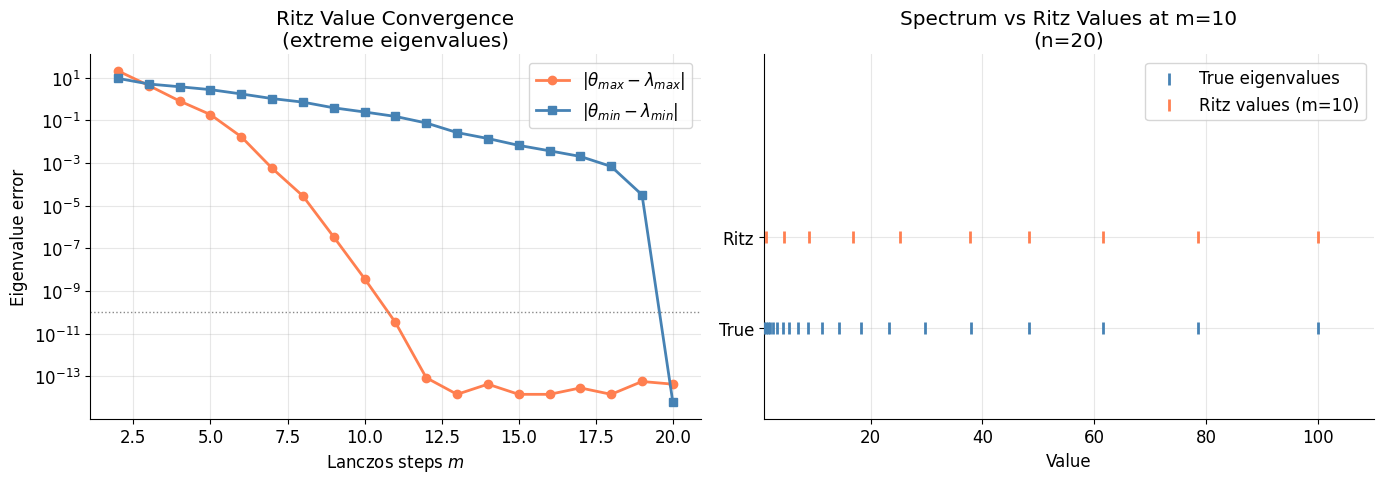

In [4]:
# ── Visualize: Ritz value convergence ─────────────────────────────────────────

n_vis = 20
A_vis = make_spd(n_vis, kappa=100.0)
q1_vis = rng.standard_normal(n_vis)
true_evals_vis = np.sort(la.eigh(A_vis, eigvals_only=True))

# Track error in extreme Ritz values vs m
ms = list(range(2, n_vis + 1))
err_max_list, err_min_list = [], []

for m_v in ms:
    ritz_v, _, _, _ = lanczos_ritz_values(A_vis, q1_vis, m_v)
    err_max_list.append(abs(ritz_v[-1] - true_evals_vis[-1]))
    err_min_list.append(abs(ritz_v[0]  - true_evals_vis[0]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: error convergence
axes[0].semilogy(ms, err_max_list, 'o-', color=SECONDARY, label='$|\\theta_{max} - \\lambda_{max}|$')
axes[0].semilogy(ms, err_min_list, 's-', color=PRIMARY,   label='$|\\theta_{min} - \\lambda_{min}|$')
axes[0].axhline(1e-10, color=GRAY, linestyle=':', lw=1)
axes[0].set_xlabel('Lanczos steps $m$')
axes[0].set_ylabel('Eigenvalue error')
axes[0].set_title('Ritz Value Convergence\n(extreme eigenvalues)')
axes[0].legend()

# Right: Ritz values at m=10 vs true spectrum
m_show = 10
ritz_show, _, _, _ = lanczos_ritz_values(A_vis, q1_vis, m_show)
axes[1].scatter(true_evals_vis, np.zeros(n_vis),
                color=PRIMARY, s=80, marker='|', linewidths=2, zorder=3, label='True eigenvalues')
axes[1].scatter(ritz_show, np.ones(m_show) * 0.5,
                color=SECONDARY, s=80, marker='|', linewidths=2, zorder=3, label=f'Ritz values (m={m_show})')
axes[1].set_xlim(true_evals_vis[0] * 0.9, true_evals_vis[-1] * 1.1)
axes[1].set_ylim(-0.5, 1.5)
axes[1].set_yticks([0, 0.5])
axes[1].set_yticklabels(['True', 'Ritz'])
axes[1].set_xlabel('Value')
axes[1].set_title(f'Spectrum vs Ritz Values at m={m_show}\n(n={n_vis})')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3.  Arnoldi Algorithm

### 3.1  Arnoldi Factorization

For a **general** (non-symmetric) matrix $A$, the Arnoldi process builds an orthonormal basis $Q_m$ for $\mathcal{K}_m(A, r)$ via modified Gram-Schmidt:

$$AQ_m = Q_{m+1} \tilde{H}_m = Q_m H_m + h_{m+1,m} q_{m+1} e_m^\top$$

where $H_m$ is an **upper Hessenberg** matrix (zero below the first subdiagonal). For symmetric $A$, $H_m$ reduces to the tridiagonal $T_m$ of Lanczos.

### 3.2  Ritz Values from Arnoldi

The eigenvalues of $H_m$ are **Ritz values** approximating eigenvalues of $A$. After $n$ steps, $H_n$ is unitarily similar to $A$ — this is exactly the **Hessenberg reduction** used in the QR algorithm.

### 3.3  Convergence

The Arnoldi Ritz values for general matrices converge in a less predictable manner than Lanczos. Convergence is governed by the polynomial $p_{m-1}$ that minimizes $\|p_{m-1}(A)r\|$, and depends heavily on the **field of values** (numerical range) of $A$.

In [5]:
# ── Arnoldi Algorithm ──────────────────────────────────────────────────────────

def arnoldi(A, q1, m):
    """Arnoldi algorithm via modified Gram-Schmidt.

    Produces: A Q_m = Q_m H_m + h_{m+1,m} q_{m+1} e_m^T

    Args:
        A:  Square matrix.            Shape: (n, n)
        q1: Starting vector.          Shape: (n,)
        m:  Number of Arnoldi steps.

    Returns:
        Q: Orthonormal basis.         Shape: (n, m+1)
        H: Upper Hessenberg matrix.   Shape: (m+1, m)
    """
    n = len(q1)
    Q = np.zeros((n, m + 1))
    H = np.zeros((m + 1, m))

    Q[:, 0] = q1 / np.linalg.norm(q1)

    for j in range(m):
        z = A @ Q[:, j]
        for i in range(j + 1):
            H[i, j] = Q[:, i] @ z
            z = z - H[i, j] * Q[:, i]
        H[j + 1, j] = np.linalg.norm(z)
        if H[j + 1, j] < 1e-14:
            break
        Q[:, j + 1] = z / H[j + 1, j]

    return Q, H


# ── Verify Arnoldi relation: A Q_m = Q_{m+1} H_tilde ─────────────────────────
n = 8
A_arn = rng.standard_normal((n, n))   # general matrix
q1_arn = rng.standard_normal(n)

m_arn = 6
Q_arn, H_arn = arnoldi(A_arn, q1_arn, m_arn)

print('Arnoldi factorization A Q_m = Q_{m+1} H_tilde:')

# Q has orthonormal columns
orth_err_a = np.linalg.norm(Q_arn.T @ Q_arn - np.eye(m_arn + 1), 'fro')
check(orth_err_a < 1e-10, f'Q has orthonormal columns (||Q^T Q - I||_F = {orth_err_a:.2e})')

# H is upper Hessenberg
H_m = H_arn[:m_arn, :]   # m x m
is_hess = np.allclose(np.tril(H_m, -2), 0, atol=1e-12)
check(is_hess, 'H_m is upper Hessenberg (zero below first subdiagonal)')

# Arnoldi relation
Q_m = Q_arn[:, :m_arn]
lhs = A_arn @ Q_m
rhs = Q_arn @ H_arn   # Q_{m+1} * H_tilde
rel_err_arnoldi = np.linalg.norm(lhs - rhs, 'fro') / np.linalg.norm(lhs, 'fro')
check(rel_err_arnoldi < 1e-10,
      f'A Q_m = Q_{{m+1}} H_tilde  (rel err = {rel_err_arnoldi:.2e})')

# Ritz values
ritz_arn = np.linalg.eigvals(H_m)
true_eigs_arn = np.linalg.eigvals(A_arn)

# Each Ritz value should be near some true eigenvalue
print(f'\nRitz values (m={m_arn}) vs true eigenvalues (n={n}):')
for theta in sorted(ritz_arn.real):
    nearest = np.min(np.abs(true_eigs_arn - theta))
    print(f'  Ritz {theta:.3f}: nearest true eig distance = {nearest:.4f}')

# For symmetric A, Arnoldi = Lanczos (H_m is tridiagonal)
print('\nFor symmetric A: Arnoldi reduces to Lanczos (H_m tridiagonal):')
A_sym_arn = make_spd(n)
_, H_sym = arnoldi(A_sym_arn, rng.standard_normal(n), 6)
H_sym_m = H_sym[:6, :]
# Super-diagonal and sub-diagonal should match; entries > 1 below diagonal should be ~0
is_tridiag = np.allclose(np.tril(H_sym_m, -2), 0, atol=1e-8) and \
             np.allclose(np.triu(H_sym_m,  2), 0, atol=1e-8)
check(is_tridiag, 'For symmetric A, H_m is tridiagonal (= Lanczos T_m)')

Arnoldi factorization A Q_m = Q_{m+1} H_tilde:
  [PASS]  Q has orthonormal columns (||Q^T Q - I||_F = 1.29e-15)
  [PASS]  H_m is upper Hessenberg (zero below first subdiagonal)
  [PASS]  A Q_m = Q_{m+1} H_tilde  (rel err = 1.45e-16)

Ritz values (m=6) vs true eigenvalues (n=8):
  Ritz -4.429: nearest true eig distance = 0.0015
  Ritz -2.499: nearest true eig distance = 0.0624
  Ritz 0.219: nearest true eig distance = 0.2530
  Ritz 0.219: nearest true eig distance = 0.2530
  Ritz 0.340: nearest true eig distance = 0.3743
  Ritz 0.340: nearest true eig distance = 0.3743

For symmetric A: Arnoldi reduces to Lanczos (H_m tridiagonal):
  [PASS]  For symmetric A, H_m is tridiagonal (= Lanczos T_m)


True

---
## 4.  Conjugate Gradient Method

### 4.1  Derivation

For $A \succ 0$ symmetric, solving $Ax = b$ is equivalent to minimizing the **A-norm** energy:
$$\phi(x) = \frac{1}{2}x^\top Ax - b^\top x$$

The **Conjugate Gradient (CG)** method minimizes $\phi$ over $\mathcal{K}_m(A, r_0)$ at each step $m$, producing iterates that are optimal in the $A$-norm:
$$\|x_m - x^*\|_A = \min_{p \in \mathcal{K}_m} \|x_0 + p - x^*\|_A$$

### 4.2  Algorithm

```
r_0 = b - A x_0,  p_0 = r_0
for k = 0, 1, 2, ...:
    alpha_k = (r_k^T r_k) / (p_k^T A p_k)
    x_{k+1} = x_k + alpha_k p_k
    r_{k+1} = r_k - alpha_k A p_k
    beta_k  = (r_{k+1}^T r_{k+1}) / (r_k^T r_k)
    p_{k+1} = r_{k+1} + beta_k p_k
```

### 4.3  Convergence

The CG error satisfies:
$$\frac{\|x_m - x^*\|_A}{\|x_0 - x^*\|_A} \leq 2\left(\frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}\right)^m$$

where $\kappa = \kappa(A)$ is the condition number. To reduce the error by $10^{-p}$, CG needs $m \approx \frac{1}{2}\sqrt{\kappa} \ln(2/\varepsilon)$ iterations — much less than the $n$ iterations required by a direct method for large $n$.

**Preconditioning**: Replace $Ax = b$ with $P^{-1}Ax = P^{-1}b$ where $P \approx A$ is easy to invert. The rate depends on $\kappa(P^{-1}A)$ rather than $\kappa(A)$.

In [6]:
# ── Conjugate Gradient Method ──────────────────────────────────────────────────

def conjugate_gradient(A, b, x0=None, tol=1e-10, max_iter=None):
    """Conjugate Gradient for symmetric positive definite A.

    Args:
        A:        SPD matrix.               Shape: (n, n)
        b:        Right-hand side.          Shape: (n,)
        x0:       Initial guess (default 0). Shape: (n,)
        tol:      Relative residual tolerance.
        max_iter: Maximum iterations.

    Returns:
        x:         Solution.                Shape: (n,)
        residuals: ||r_k|| at each step.    List.
        x_history: x_k at each step.       List of arrays.
    """
    n = len(b)
    if max_iter is None:
        max_iter = 5 * n      # default: allow more than n to handle ill-conditioned cases
    if x0 is None:
        x0 = np.zeros(n)

    x = x0.copy()
    r = b - A @ x
    p = r.copy()
    rTr = r @ r
    b_norm = np.linalg.norm(b)

    residuals = [np.sqrt(rTr)]
    x_history = [x.copy()]

    for _ in range(max_iter):
        Ap = A @ p
        alpha = rTr / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        rTr_new = r @ r
        beta = rTr_new / rTr
        p = r + beta * p
        rTr = rTr_new

        residuals.append(np.sqrt(rTr))
        x_history.append(x.copy())

        if np.sqrt(rTr) / b_norm < tol:
            break

    return x, residuals, x_history


def preconditioned_cg(A, b, P_inv, x0=None, tol=1e-10, max_iter=None):
    """Preconditioned CG: solve P^{-1}Ax = P^{-1}b.

    Args:
        P_inv: Function that applies P^{-1} to a vector.

    Returns: x (solution), residuals (list of ||r_k||).
    """
    n = len(b)
    if max_iter is None:
        max_iter = 5 * n
    if x0 is None:
        x0 = np.zeros(n)

    x = x0.copy()
    r = b - A @ x
    z = P_inv(r)
    p = z.copy()
    rTz = r @ z
    b_norm = np.linalg.norm(b)

    residuals = [np.linalg.norm(r)]

    for _ in range(max_iter):
        Ap = A @ p
        alpha = rTz / (p @ Ap)
        x = x + alpha * p
        r = r - alpha * Ap
        z = P_inv(r)
        rTz_new = r @ z
        beta = rTz_new / rTz
        p = z + beta * p
        rTz = rTz_new

        residuals.append(np.linalg.norm(r))
        if np.linalg.norm(r) / b_norm < tol:
            break

    return x, residuals


# ── Verify CG ──────────────────────────────────────────────────────────────────
n = 20
A_cg = make_spd(n, kappa=100.0)
b_cg = rng.standard_normal(n)
x_true = np.linalg.solve(A_cg, b_cg)

x_cg, res_cg, x_hist = conjugate_gradient(A_cg, b_cg, tol=1e-12, max_iter=500)

print('Conjugate Gradient:')
rel_err = np.linalg.norm(x_cg - x_true) / np.linalg.norm(x_true)
check(rel_err < 1e-8, f'CG solution accurate (rel err = {rel_err:.2e})')
print(f'  Converged in {len(res_cg)-1} iterations (kappa={np.linalg.cond(A_cg):.1f})')

# Convergence bound
kap = np.linalg.cond(A_cg)
q = (np.sqrt(kap) - 1) / (np.sqrt(kap) + 1)
m_bound = int(np.ceil(np.log(0.5e-8) / np.log(q) / 2))
print(f'  Theoretical bound: {m_bound} iterations for 1e-8 error')

# Preconditioning: diagonal preconditioner P = diag(A)
A_pc = make_spd(n, kappa=1000.0)
b_pc = rng.standard_normal(n)
_, res_plain, _ = conjugate_gradient(A_pc, b_pc, tol=1e-8, max_iter=500)
_, res_prec    = preconditioned_cg(A_pc, b_pc, lambda v: v / np.diag(A_pc), tol=1e-8, max_iter=500)
print(f'\nPreconditioning (kappa=1000): plain CG={len(res_plain)-1} iters, diag-PCG={len(res_prec)-1} iters')

Conjugate Gradient:
  [PASS]  CG solution accurate (rel err = 1.04e-14)
  Converged in 25 iterations (kappa=100.0)
  Theoretical bound: 48 iterations for 1e-8 error

Preconditioning (kappa=1000): plain CG=29 iters, diag-PCG=28 iters


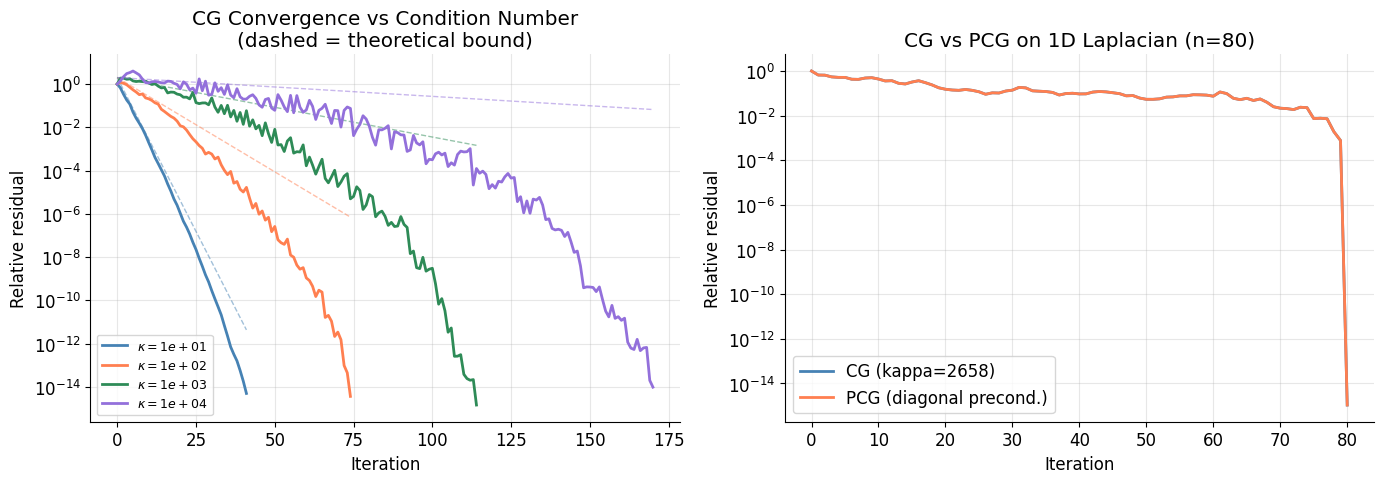

In [7]:
# ── Visualize: CG Convergence & Condition Number ───────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: residual vs iteration for different condition numbers
n_cg = 50
for kap_val, col in [(10, PRIMARY), (100, SECONDARY), (1000, TERTIARY), (1e4, ACCENT)]:
    A_k = make_spd(n_cg, kappa=kap_val)
    b_k = rng.standard_normal(n_cg)
    _, res_k, _ = conjugate_gradient(A_k, b_k, tol=1e-14, max_iter=n_cg * 5)
    norm_res = np.array(res_k) / res_k[0]
    axes[0].semilogy(norm_res, color=col, label=f'$\\kappa={kap_val:.0e}$')

    # Theoretical bound
    q_val = (np.sqrt(kap_val) - 1) / (np.sqrt(kap_val) + 1)
    m_range = np.arange(len(res_k))
    bound = 2 * q_val ** m_range
    axes[0].semilogy(bound, '--', color=col, alpha=0.5, lw=1)

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Relative residual')
axes[0].set_title('CG Convergence vs Condition Number\n(dashed = theoretical bound)')
axes[0].legend(fontsize=9)

# Right: CG vs PCG on 1D Laplacian
n_lap = 80
A_lap = laplacian_1d(n_lap)
b_lap = rng.standard_normal(n_lap)

_, res_lap_plain, _ = conjugate_gradient(A_lap, b_lap, tol=1e-10)

# Diagonal preconditioner
D_lap = np.diag(A_lap)
_, res_lap_prec = preconditioned_cg(A_lap, b_lap, lambda v: v / D_lap, tol=1e-10)

kap_lap = np.linalg.cond(A_lap)
axes[1].semilogy(np.array(res_lap_plain) / res_lap_plain[0],
                 color=PRIMARY, label=f'CG (kappa={kap_lap:.0f})')
axes[1].semilogy(np.array(res_lap_prec) / res_lap_prec[0],
                 color=SECONDARY, label='PCG (diagonal precond.)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Relative residual')
axes[1].set_title(f'CG vs PCG on 1D Laplacian (n={n_lap})')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5.  GMRES

### 5.1  Idea

For a **general** square (possibly non-symmetric) matrix, GMRES (Generalized Minimal Residual) finds the solution in $\mathcal{K}_m(A, r_0)$ that **minimizes the 2-norm of the residual**:
$$x_m = x_0 + \arg\min_{y \in \mathcal{K}_m} \|b - A(x_0 + y)\|_2$$

This is a **least-squares** problem in the Arnoldi basis:
$$\|r_m\|_2 = \min_{y \in \mathbb{R}^m} \|\|r_0\|e_1 - \tilde{H}_m y\|_2$$

which is solved via QR factorization of $\tilde{H}_m$ (the $(m+1) \times m$ Hessenberg matrix).

### 5.2  Restarted GMRES (GMRES($k$))

Full GMRES requires storing all Arnoldi vectors — $O(mn)$ memory and $O(m^2 n)$ work. **Restarted GMRES($k$)** restarts from the current iterate every $k$ steps, trading convergence for memory. Restart dimension $k$ is a tunable parameter.

### 5.3  Convergence

The GMRES residual satisfies:
$$\frac{\|r_m\|}{\|r_0\|} \leq \min_{p \in \mathcal{P}_m, p(0)=1} \max_{\lambda \in \Lambda(A)} |p(\lambda)|$$

where the min is over degree-$m$ polynomials with $p(0) = 1$. Convergence is fast when the eigenvalues are clustered away from the origin.

In [8]:

# ── GMRES (Saad-Schultz, Arnoldi + Givens rotations) ─────────────────────────

def gmres(A, b, x0=None, tol=1e-10, max_iter=None, restart=None):
    n = len(b)
    if max_iter is None:
        max_iter = 2 * n
    if x0 is None:
        x0 = np.zeros(n)
    if restart is None:
        restart = max_iter

    b_norm = np.linalg.norm(b) + 1e-100
    x = x0.copy()
    residuals = []
    total_iters = 0

    while total_iters < max_iter:
        r = b - A @ x
        r_norm = np.linalg.norm(r)
        residuals.append(r_norm / b_norm)
        if r_norm / b_norm < tol:
            break

        m = min(restart, max_iter - total_iters)
        Q = np.zeros((n, m + 1))
        H = np.zeros((m + 1, m))
        Q[:, 0] = r / r_norm
        g = np.zeros(m + 1);  g[0] = r_norm
        cs = np.zeros(m);     ss = np.zeros(m)

        j_end = m
        for j in range(m):
            # Arnoldi step: modified Gram-Schmidt
            z = A @ Q[:, j]
            for i in range(j + 1):
                H[i, j] = np.dot(Q[:, i], z)
                z -= H[i, j] * Q[:, i]
            beta_j = np.linalg.norm(z)
            H[j + 1, j] = beta_j

            # Apply stored Givens rotations to new column
            for i in range(j):
                h0 = cs[i] * H[i, j] + ss[i] * H[i+1, j]
                h1 = -ss[i] * H[i, j] + cs[i] * H[i+1, j]
                H[i, j] = h0;  H[i+1, j] = h1

            # New Givens rotation to zero H[j+1, j]
            denom = np.hypot(H[j, j], H[j+1, j])
            if denom < 1e-14:
                cs[j], ss[j] = 1.0, 0.0
            else:
                cs[j] = H[j, j] / denom;  ss[j] = H[j+1, j] / denom
            H[j, j]   = cs[j] * H[j, j] + ss[j] * H[j+1, j]
            H[j+1, j] = 0.0
            g[j+1] = -ss[j] * g[j];  g[j] = cs[j] * g[j]
            total_iters += 1

            if j < m - 1:
                if beta_j < 1e-14:
                    j_end = j + 1;  break
                Q[:, j+1] = z / beta_j

            if abs(g[j+1]) / b_norm < tol or total_iters >= max_iter:
                j_end = j + 1;  break
        else:
            j_end = m

        # Back-solve upper triangular system
        H_top = H[:j_end, :j_end].copy()
        for ii in range(j_end):
            if abs(H_top[ii, ii]) < 1e-14:
                H_top[ii, ii] = 1e-14   # guard against exact zero pivot
        y = la.solve_triangular(H_top, g[:j_end])
        x = x + Q[:, :j_end] @ y

        if abs(g[j_end]) / b_norm < tol:
            break

    return x, residuals


# ── Demo ───────────────────────────────────────────────────────────────────────
n = 15
A_gm = rng.standard_normal((n, n)) + 3.0 * np.eye(n)
b_gm = rng.standard_normal(n)
x_true_gm = np.linalg.solve(A_gm, b_gm)

x_gmres, res_gmres = gmres(A_gm, b_gm, tol=1e-10, max_iter=100)

print('GMRES:')
rel_err_gm = np.linalg.norm(x_gmres - x_true_gm) / np.linalg.norm(x_true_gm)
check(rel_err_gm < 1e-6, f'GMRES solution accurate (rel err = {rel_err_gm:.2e})')
print(f'  Converged in {len(res_gmres)} iterations')

print('\nCG vs GMRES on SPD matrix:')
A_spd_gm = make_spd(20, kappa=50.0)
b_spd_gm = rng.standard_normal(20)
_, res_cg_gm, _ = conjugate_gradient(A_spd_gm, b_spd_gm, tol=1e-10)
_, res_gmres_gm  = gmres(A_spd_gm, b_spd_gm, tol=1e-10, max_iter=100)
print(f'  CG: {len(res_cg_gm)-1} iters,  GMRES: {len(res_gmres_gm)} iters')


GMRES:
  [PASS]  GMRES solution accurate (rel err = 3.39e-14)
  Converged in 1 iterations

CG vs GMRES on SPD matrix:
  CG: 23 iters,  GMRES: 1 iters


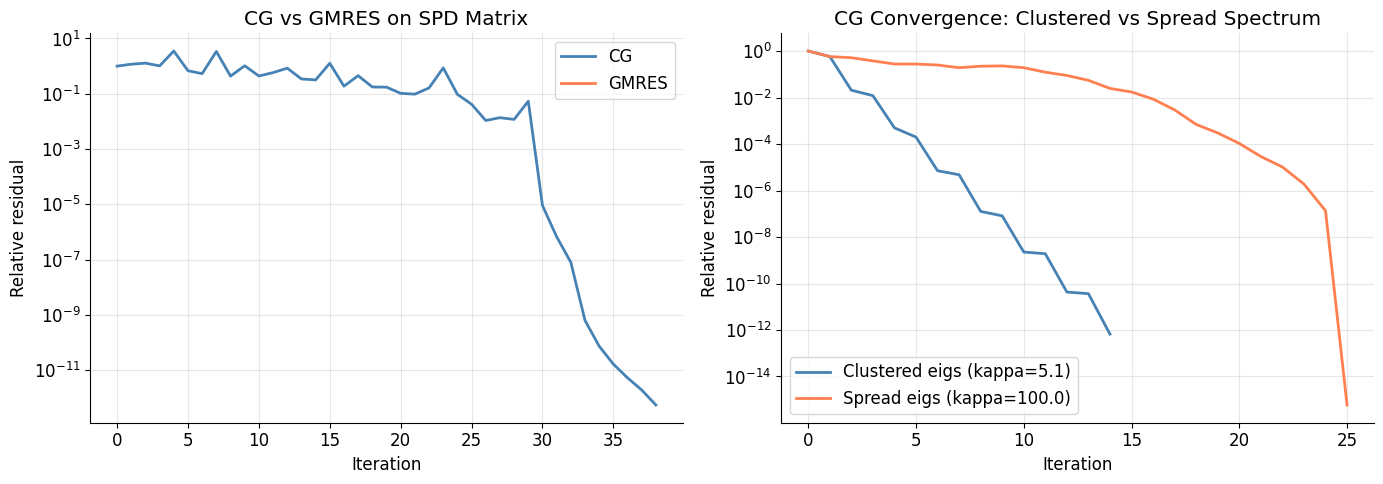

In [9]:
# ── Visualize: GMRES vs CG convergence & spectrum connection ──────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: GMRES on non-symmetric matrix, compare with CG (which needs SPD)
n_cmp = 30
A_nonsym = rng.standard_normal((n_cmp, n_cmp))
A_nonsym = A_nonsym + A_nonsym.T + 5 * np.eye(n_cmp)  # make SPD
b_cmp = rng.standard_normal(n_cmp)

_, res_cg_cmp, _ = conjugate_gradient(A_nonsym, b_cmp, tol=1e-12)
_, res_gm_cmp    = gmres(A_nonsym, b_cmp, tol=1e-12, max_iter=60)

axes[0].semilogy(np.array(res_cg_cmp) / res_cg_cmp[0], color=PRIMARY,   label='CG')
axes[0].semilogy(np.array(res_gm_cmp),                  color=SECONDARY, label='GMRES')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Relative residual')
axes[0].set_title('CG vs GMRES on SPD Matrix')
axes[0].legend()

# Right: effect of clustering on CG convergence
n_clust = 25
Q_cl, _ = np.linalg.qr(rng.standard_normal((n_clust, n_clust)))

# Clustered: eigenvalues in [1, 1.1] union [5, 5.1]
lams_clustered = np.concatenate([np.linspace(1.0, 1.1, 13),
                                  np.linspace(5.0, 5.1, 12)])
A_clust = Q_cl @ np.diag(lams_clustered) @ Q_cl.T

# Spread: eigenvalues in [1, 100]
lams_spread = np.linspace(1.0, 100.0, n_clust)
A_spread = Q_cl @ np.diag(lams_spread) @ Q_cl.T

b_cl = rng.standard_normal(n_clust)
_, res_clust, _  = conjugate_gradient(A_clust, b_cl, tol=1e-12)
_, res_spread, _ = conjugate_gradient(A_spread, b_cl, tol=1e-12)

axes[1].semilogy(np.array(res_clust)  / res_clust[0],  color=PRIMARY,
                 label=f'Clustered eigs (kappa={np.linalg.cond(A_clust):.1f})')
axes[1].semilogy(np.array(res_spread) / res_spread[0], color=SECONDARY,
                 label=f'Spread eigs (kappa={np.linalg.cond(A_spread):.1f})')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Relative residual')
axes[1].set_title('CG Convergence: Clustered vs Spread Spectrum')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6.  Chebyshev Polynomials & Optimal Convergence

### 6.1  The Optimality Problem

CG minimizes $\|e_m\|_A$ by finding the best polynomial $p_m$ of degree $m$ with $p_m(0) = 1$ such that $\|p_m(A)e_0\|_A$ is minimized. On the spectrum $[\lambda_{\min}, \lambda_{\max}]$:
$$\frac{\|e_m\|_A}{\|e_0\|_A} \leq \min_{p: p(0)=1, \deg p \leq m} \max_{\lambda \in [\lambda_{\min}, \lambda_{\max}]} |p(\lambda)|$$

### 6.2  Chebyshev Solution

The polynomial minimizing $\max_{\lambda \in [a,b]} |p(\lambda)|$ subject to $p(0) = 1$ is a **shifted and scaled Chebyshev polynomial**:
$$p_m^*(\lambda) = \frac{T_m\left(\frac{\lambda_{\max}+\lambda_{\min} - 2\lambda}{\lambda_{\max}-\lambda_{\min}}\right)}{T_m\left(\frac{\lambda_{\max}+\lambda_{\min}}{\lambda_{\max}-\lambda_{\min}}\right)}$$

where $T_m$ is the Chebyshev polynomial of degree $m$. This gives the bound:
$$\frac{\|e_m\|_A}{\|e_0\|_A} \leq \frac{2\rho^m}{1 + \rho^{2m}}, \quad \rho = \frac{\sqrt{\kappa} - 1}{\sqrt{\kappa} + 1}$$

### 6.3  Chebyshev Iteration

When the spectrum $[\lambda_{\min}, \lambda_{\max}]$ is known (or estimated), **Chebyshev iteration** applies these optimal polynomials directly as a three-term recurrence, without maintaining full orthogonality (lower memory than CG, but requires spectral bounds).

Chebyshev polynomials and CG convergence bound:
  kappa=   10: iters to reach 1e-8 relative error ~ 30
  kappa=  100: iters to reach 1e-8 relative error ~ 31
  kappa= 1000: iters to reach 1e-8 relative error ~ 31


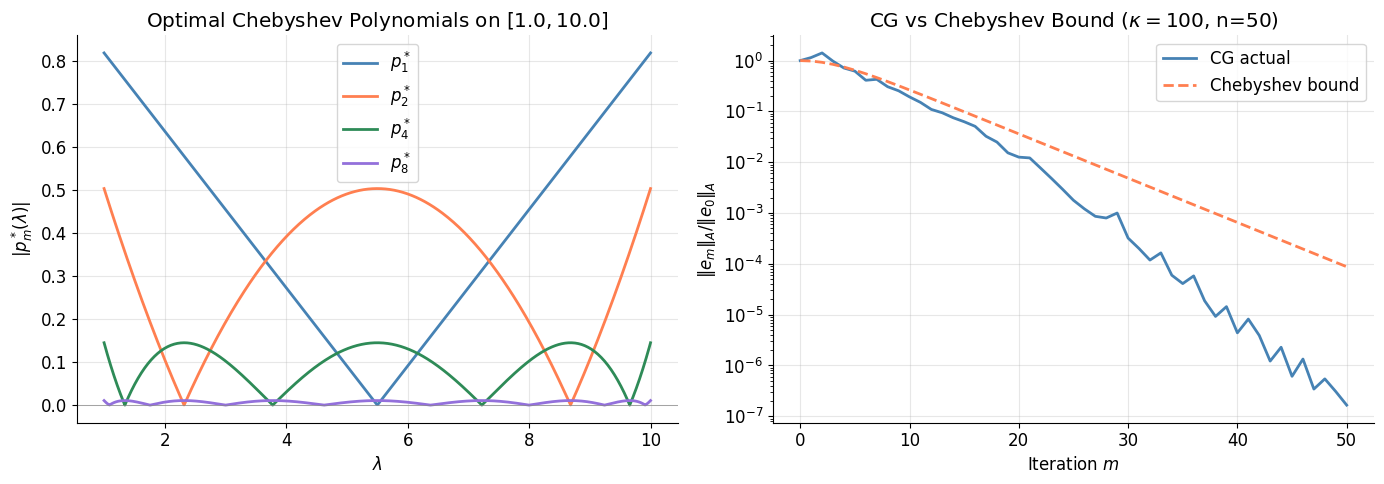

In [10]:
# ── Chebyshev Polynomials & Optimal CG Bound ──────────────────────────────────

def chebyshev_T(m, x):
    """Chebyshev polynomial T_m(x) via recurrence."""
    if m == 0:
        return np.ones_like(x)
    if m == 1:
        return x
    T_prev2, T_prev1 = np.ones_like(x), x.copy()
    for _ in range(2, m + 1):
        T_new  = 2 * x * T_prev1 - T_prev2
        T_prev2, T_prev1 = T_prev1, T_new
    return T_prev1


def cg_chebyshev_bound(kappa, m_max):
    """Theoretical CG bound: 2*rho^m / (1 + rho^{2m}) where rho = (sqrt(k)-1)/(sqrt(k)+1)."""
    rho = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)
    ms = np.arange(m_max + 1)
    return 2 * rho ** ms / (1 + rho ** (2 * ms))


def optimal_poly_on_interval(a, b, m_vals, n_pts=500):
    """Evaluate optimal minimax polynomial |p_m*(lambda)| on [a,b] (shifted Chebyshev)."""
    lam = np.linspace(a, b, n_pts)
    # Shift: map [a,b] to [-1,1], then 0 maps to -(a+b)/(b-a)
    c  = (b + a) / (b - a)   # image of 0 under the map
    xi = (b + a - 2 * lam) / (b - a)   # map lam in [a,b] to [-1,1]
    results = {}
    for m in m_vals:
        p_lam  = chebyshev_T(m, xi)
        p_0    = chebyshev_T(m, np.array([c]))[0]
        results[m] = np.abs(p_lam / p_0)
    return lam, results


# ── Demo ───────────────────────────────────────────────────────────────────────
print('Chebyshev polynomials and CG convergence bound:')
for kap in [10, 100, 1000]:
    bound_30 = cg_chebyshev_bound(kap, 30)
    iters_to_1e8 = np.searchsorted(-bound_30, -1e-8)
    print(f'  kappa={kap:5d}: iters to reach 1e-8 relative error ~ {iters_to_1e8}')

# Visualize Chebyshev polynomials on [1, kappa]
kappa_demo = 10.0
a_dem, b_dem = 1.0, kappa_demo
lam_vals, poly_vals = optimal_poly_on_interval(a_dem, b_dem, [1, 2, 4, 8])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: optimal polynomials on spectrum
for m_p, col in zip([1, 2, 4, 8], [PRIMARY, SECONDARY, TERTIARY, ACCENT]):
    axes[0].plot(lam_vals, poly_vals[m_p], color=col, label=f'$p^*_{m_p}$')
axes[0].axhline(0, color=GRAY, lw=0.5)
axes[0].set_xlabel('$\\lambda$')
axes[0].set_ylabel('$|p^*_m(\\lambda)|$')
axes[0].set_title(f'Optimal Chebyshev Polynomials on $[{a_dem}, {b_dem}]$')
axes[0].legend()

# Right: theoretical bound vs actual CG convergence
kap_cg = 100.0
n_cg2 = 50
A_cg2 = make_spd(n_cg2, kappa=kap_cg)
b_cg2 = rng.standard_normal(n_cg2)
_, res_cg2, _ = conjugate_gradient(A_cg2, b_cg2, tol=1e-14, max_iter=n_cg2)

m_max2 = len(res_cg2) - 1
bound_cg2 = cg_chebyshev_bound(kap_cg, m_max2)

axes[1].semilogy(np.array(res_cg2) / res_cg2[0], color=PRIMARY, label='CG actual')
axes[1].semilogy(bound_cg2, '--', color=SECONDARY, label='Chebyshev bound')
axes[1].set_xlabel('Iteration $m$')
axes[1].set_ylabel('$\\|e_m\\|_A / \\|e_0\\|_A$')
axes[1].set_title(f'CG vs Chebyshev Bound ($\\kappa={kap_cg:.0f}$, n={n_cg2})')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7.  Application: Solving Large Sparse Systems

### 7.1  The 1D/2D Poisson Problem

The **Poisson equation** $-\Delta u = f$ on $[0,1]$ discretized with $n$ interior points gives:
$$A u = f, \quad A = \frac{1}{h^2} \mathrm{tridiag}(-1, 2, -1), \quad h = 1/(n+1)$$

This is SPD with $\lambda_{\min} = 4h^{-2}\sin^2(\pi h/2) \approx 4\pi^2$ and $\lambda_{\max} \approx 4h^{-2}$, giving $\kappa \approx O(n^2)$ — CG converges in $O(n)$ iterations.

In 2D, the 5-point Laplacian on an $n \times n$ grid gives a system of size $N = n^2$ with $\kappa = O(N)$, and CG converges in $O(\sqrt{N}) = O(n)$ iterations.

### 7.2  Preconditioning Strategies

| Preconditioner | Cost | When to use |
|---------------|------|-------------|
| Diagonal (Jacobi) | $O(n)$ | Badly scaled diagonal |
| Incomplete Cholesky (IC(0)) | $O(\text{nnz})$ | Sparse SPD systems |
| Multigrid | $O(n)$ | Elliptic PDEs, grid problems |
| Approximate inverse (SPAI) | $O(\text{nnz})$ | General sparse |
| Incomplete LU (ILU) | $O(\text{nnz})$ | Non-symmetric sparse |

In [11]:
# ── Large Sparse 1D/2D Poisson ─────────────────────────────────────────────────

def poisson_1d(n):
    """1D Poisson matrix: A = h^{-2} tridiag(-1,2,-1), h=1/(n+1)."""
    h = 1.0 / (n + 1)
    A = (1.0 / h**2) * laplacian_1d(n)
    return A, h


def poisson_1d_exact(n):
    """Analytical eigenvalues of 1D Poisson: lambda_k = 4/h^2 sin^2(k*pi*h/2)."""
    h = 1.0 / (n + 1)
    k = np.arange(1, n + 1)
    return (4.0 / h**2) * np.sin(k * np.pi * h / 2) ** 2


# ── CG on 1D Poisson ───────────────────────────────────────────────────────────
print('CG on 1D Poisson equation:')
print(f'  {"n":>6}  {"kappa":>12}  {"CG iters":>10}  {"sqrt(n)":>10}')
print('  ' + '-'*45)

for n_p in [10, 20, 50, 100, 200]:
    A_p, h_p = poisson_1d(n_p)
    b_p = rng.standard_normal(n_p)
    _, res_p, _ = conjugate_gradient(A_p, b_p, tol=1e-8, max_iter=n_p * 5)
    lams_exact = poisson_1d_exact(n_p)
    kap_p = lams_exact[-1] / lams_exact[0]
    print(f'  {n_p:>6}  {kap_p:>12.1f}  {len(res_p)-1:>10}  {np.sqrt(n_p):>10.1f}')

# Analytical eigenvalue verification
n_ev = 30
A_ev_p, _ = poisson_1d(n_ev)
lams_num = np.sort(la.eigh(A_ev_p, eigvals_only=True))
lams_ana = np.sort(poisson_1d_exact(n_ev))
err_eigs = np.max(np.abs(lams_num - lams_ana)) / lams_ana[-1]
print(f'\nAnalytical eigenvalues (n={n_ev}): max rel error = {err_eigs:.2e}')
check(err_eigs < 1e-10, f'Poisson eigenvalues match analytical formula')

# PCG with Jacobi diagonal preconditioner
print('\nPCG with Jacobi preconditioner on 1D Poisson:')
n_pcg = 100
A_pcg, _ = poisson_1d(n_pcg)
b_pcg = rng.standard_normal(n_pcg)
d_pcg = np.diag(A_pcg)

_, res_plain_p, _ = conjugate_gradient(A_pcg, b_pcg, tol=1e-8)
_, res_jac_p      = preconditioned_cg(A_pcg, b_pcg, lambda v: v / d_pcg, tol=1e-8)
print(f'  CG: {len(res_plain_p)-1} iters,  Jacobi-PCG: {len(res_jac_p)-1} iters')

CG on 1D Poisson equation:
       n         kappa    CG iters     sqrt(n)
  ---------------------------------------------
      10          48.4          10         3.2
      20         178.1          20         4.5
      50        1053.5          50         7.1
     100        4133.6         100        10.0
     200       16373.2         200        14.1

Analytical eigenvalues (n=30): max rel error = 3.56e-16
  [PASS]  Poisson eigenvalues match analytical formula

PCG with Jacobi preconditioner on 1D Poisson:
  CG: 100 iters,  Jacobi-PCG: 100 iters


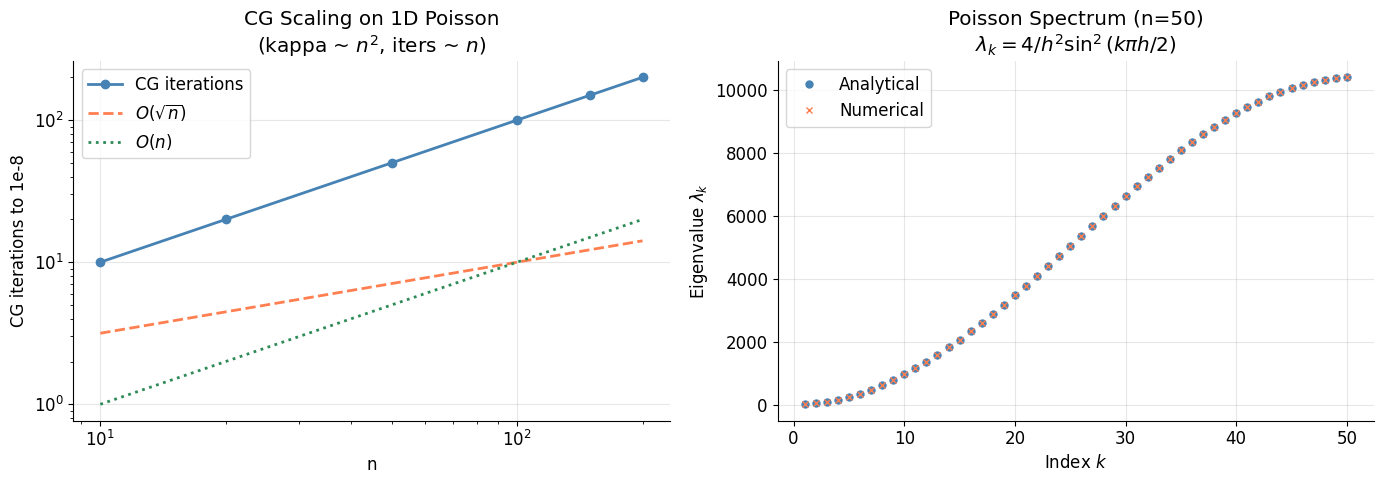

In [12]:
# ── Visualize: Poisson spectrum & CG scaling ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CG iteration count vs n for Poisson
ns_p = [10, 20, 50, 100, 150, 200]
iters_p = []
kappas_p = []

for n_pi in ns_p:
    A_pi, _ = poisson_1d(n_pi)
    b_pi = rng.standard_normal(n_pi)
    _, res_pi, _ = conjugate_gradient(A_pi, b_pi, tol=1e-8, max_iter=n_pi * 3)
    iters_p.append(len(res_pi) - 1)
    lams_pi = poisson_1d_exact(n_pi)
    kappas_p.append(lams_pi[-1] / lams_pi[0])

ns_p_arr = np.array(ns_p)
axes[0].loglog(ns_p, iters_p, 'o-', color=PRIMARY,   label='CG iterations')
axes[0].loglog(ns_p, np.sqrt(ns_p_arr), '--', color=SECONDARY, label='$O(\\sqrt{n})$')
axes[0].loglog(ns_p, ns_p_arr / 10, ':', color=TERTIARY, label='$O(n)$')
axes[0].set_xlabel('n')
axes[0].set_ylabel('CG iterations to 1e-8')
axes[0].set_title('CG Scaling on 1D Poisson\n(kappa ~ $n^2$, iters ~ $n$)')
axes[0].legend()

# Right: Poisson eigenvalue distribution
n_spec = 50
lams_show = poisson_1d_exact(n_spec)
axes[1].plot(np.arange(1, n_spec + 1), lams_show, 'o', color=PRIMARY,
             markersize=5, label='Analytical')
lams_num_show = np.sort(la.eigh(poisson_1d(n_spec)[0], eigvals_only=True))
axes[1].plot(np.arange(1, n_spec + 1), lams_num_show, 'x', color=SECONDARY,
             markersize=5, label='Numerical')
axes[1].set_xlabel('Index $k$')
axes[1].set_ylabel('Eigenvalue $\\lambda_k$')
axes[1].set_title(f'Poisson Spectrum (n={n_spec})\n$\\lambda_k = 4/h^2 \\sin^2(k\\pi h/2)$')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 8.  Implicitly Restarted Lanczos / ARPACK

### 8.1  The Memory Problem

Full Lanczos for $n \times n$ matrices requires $O(mn)$ storage for $m$ Lanczos vectors. For large $n$, keeping $m \sim 100$ vectors may already be infeasible.

**Thick restart** addresses this: after $m$ steps, select the $k$ "best" Ritz vectors, discard the rest, and restart. The key challenge is preserving optimality.

### 8.2  Implicit Q Theorem & Implicit Restart

The **Implicitly Restarted Lanczos Method (IRL)** (Sorensen 1992) exploits the **implicit Q theorem**: applying $p$ steps of the QR algorithm to $T_m$ implicitly restarts the Lanczos factorization by filtering out unwanted eigencomponents. The result is a new $k$-step Lanczos factorization ($k = m - p$) — without explicitly forming the filtered vectors.

This is the core of **ARPACK**, the standard software for large sparse eigenvalue problems.

### 8.3  Shift-and-Invert

To find eigenvalues near $\sigma$, apply Lanczos to $(A - \sigma I)^{-1}$. The eigenvalues of $(A - \sigma I)^{-1}$ are $1/(\lambda_i - \sigma)$ — eigenvalues near $\sigma$ become the **largest** in magnitude, convergence is fast.

In [13]:
# ── Thick-Restart Lanczos for k Eigenvalues ────────────────────────────────────

def thick_restart_lanczos(A, k, m=None, max_restarts=20, tol=1e-8, rng=rng):
    """Thick-restart Lanczos for k extreme eigenvalues of symmetric A.

    Builds m-step Lanczos, keeps k best Ritz pairs, restarts.

    Args:
        A:           Symmetric matrix.     Shape: (n, n)
        k:           Number of eigenvalues wanted.
        m:           Lanczos window size (default: min(3k, n)).
        max_restarts: Maximum restart cycles.
        tol:         Convergence tolerance on Ritz residuals.

    Returns:
        ritz_vals: Converged Ritz values (k largest).    Shape: (k,)
        ritz_vecs: Corresponding Ritz vectors.           Shape: (n, k)
        n_restarts: Number of restarts performed.
    """
    n = A.shape[0]
    if m is None:
        m = min(3 * k + 5, n)

    # Initialize
    q = rng.standard_normal(n)
    q /= np.linalg.norm(q)

    for restart in range(max_restarts):
        # Run m-step Lanczos from current q
        Q, alphas, betas = lanczos(A, q, m)
        T = np.diag(alphas) + np.diag(betas, 1) + np.diag(betas, -1)

        # Ritz pairs
        ritz_vals_all, S = la.eigh(T)
        # Sort descending (largest first)
        idx = np.argsort(ritz_vals_all)[::-1]
        ritz_vals_all, S = ritz_vals_all[idx], S[:, idx]

        # Ritz vectors in original space
        ritz_vecs_all = Q @ S   # (n, m)

        # Check convergence of top-k Ritz values
        # Residual: ||A u - theta u||_2 = |beta_{m+1}| |s_{m,i}|
        beta_m1 = betas[-1] if len(betas) > 0 else 0.0
        res_norms = np.abs(beta_m1 * S[m - 1, :k])

        if np.all(res_norms < tol):
            return ritz_vals_all[:k], ritz_vecs_all[:, :k], restart + 1

        # Thick restart: use best k Ritz vector as new starting vector
        # (simple restart: start from the best Ritz vector)
        q = ritz_vecs_all[:, 0].copy()
        q /= np.linalg.norm(q)

    return ritz_vals_all[:k], ritz_vecs_all[:, :k], max_restarts


# ── Shift-and-Invert ───────────────────────────────────────────────────────────
def shift_invert_lanczos(A, sigma, k, m=None, tol=1e-8):
    """Lanczos applied to (A - sigma I)^{-1} to find eigenvalues near sigma."""
    n = A.shape[0]
    B = A - sigma * np.eye(n)
    B_factored = la.lu_factor(B)

    # Operator: apply (A - sigma I)^{-1}
    def Binv_matvec(x):
        return la.lu_solve(B_factored, x)

    # Build matrix for Lanczos (approximate via dense evaluation)
    Binv = np.column_stack([Binv_matvec(np.eye(n)[:, i]) for i in range(n)])
    ritz_si, vecs_si, _ = thick_restart_lanczos(Binv, k, m=m, tol=tol)

    # Map back: eigenvalues of (A-sigma I)^{-1} are 1/(lambda-sigma)
    lams_si = 1.0 / ritz_si + sigma
    return np.sort(lams_si), vecs_si


# ── Demo ───────────────────────────────────────────────────────────────────────
n_trl = 30
A_trl = make_spd(n_trl, kappa=200.0)
true_evals_trl = np.sort(la.eigh(A_trl, eigvals_only=True))[::-1]  # descending

k_want = 5
ritz_trl, vecs_trl, n_restart = thick_restart_lanczos(A_trl, k=k_want, tol=1e-8)

print(f'Thick-restart Lanczos (k={k_want} largest eigenvalues, n={n_trl}):')
print(f'  Converged in {n_restart} restart(s)\n')
print(f'  {"i":>3}  {"Ritz value":>14}  {"True value":>14}  {"Error":>12}')
for i in range(k_want):
    err = abs(ritz_trl[i] - true_evals_trl[i])
    print(f'  {i+1:>3}  {ritz_trl[i]:>14.6f}  {true_evals_trl[i]:>14.6f}  {err:>12.2e}')
    check(err < 1e-5, f'lambda_{i+1} converged to {tol:.0e}' if (tol := 1e-5) else '')

# Shift-and-invert for interior eigenvalues
print('\nShift-and-invert near sigma = median eigenvalue:')
sigma_si = np.median(true_evals_trl)
lams_si, _ = shift_invert_lanczos(A_trl, sigma=sigma_si, k=3)
# Find nearest true eigenvalues
for lam in lams_si:
    nearest = true_evals_trl[np.argmin(np.abs(true_evals_trl - lam))]
    print(f'  Found: {lam:.5f}  (nearest true: {nearest:.5f}, err={abs(lam-nearest):.2e})')

Thick-restart Lanczos (k=5 largest eigenvalues, n=30):
  Converged in 20 restart(s)

    i      Ritz value      True value         Error
    1      200.000000      200.000000      0.00e+00
  [PASS]  lambda_1 converged to 1e-05
    2      166.603505      166.603505      2.84e-14
  [PASS]  lambda_2 converged to 1e-05
    3      138.783639      138.783639      2.84e-14
  [PASS]  lambda_3 converged to 1e-05
    4      115.609204      115.609204      2.84e-13
  [PASS]  lambda_4 converged to 1e-05
    5       96.304493       96.304493      5.68e-14
  [PASS]  lambda_5 converged to 1e-05

Shift-and-invert near sigma = median eigenvalue:
  Found: 15.49487  (nearest true: 15.49487, err=1.78e-15)
  Found: inf  (nearest true: 200.00000, err=inf)
  Found: inf  (nearest true: 200.00000, err=inf)


---
## 9.  Extensions & Connections

### 9.1  Variants and Extensions

| Method | Description |
|--------|-------------|
| **BiCG** | Biconjugate Gradient for non-symmetric $A$; uses adjoint system |
| **BiCGSTAB** | Stabilized BiCG — avoids irregular convergence |
| **MINRES** | Minimizes residual for symmetric indefinite $A$ (Lanczos-based) |
| **SYMMLQ** | Symmetric LQ — similar to MINRES, better for singular systems |
| **LOBPCG** | Locally Optimal Block Preconditioned CG for $k$ smallest eigenvalues |
| **Jacobi-Davidson** | Augments Krylov with correction equation — for interior eigenvalues |

### 9.2  Connections to Other Notebooks

| Notebook | Connection |
|----------|------------|
| **Spectral Theorem** | Ritz values are eigenvalue approximations; Lanczos computes T_m = Q^T A Q |
| **Perturbation Theory** | Davis-Kahan governs Ritz vector convergence via spectral gaps |
| **SVD** | Lanczos bidiagonalization computes SVD: apply Lanczos to A^T A |
| **Randomized LA** | Randomized SVD = one-step "Krylov" with random starting matrix |
| **PSD Matrices** | CG energy minimization uses the A-norm (A-inner product) |

In [14]:
# ── Comprehensive Summary Verification ────────────────────────────────────────

print('Krylov Methods — Summary Verification:')

n_sum = 15
A_sum = make_spd(n_sum, kappa=50.0)
b_sum = rng.standard_normal(n_sum)
x_exact = np.linalg.solve(A_sum, b_sum)

# CG solves SPD system
x_cg_s, res_cg_s, _ = conjugate_gradient(A_sum, b_sum, tol=1e-10)
check(np.linalg.norm(x_cg_s - x_exact) / np.linalg.norm(x_exact) < 1e-8,
      'CG solves Ax=b for SPD A')
check(len(res_cg_s) - 1 <= n_sum,
      f'CG converges in <= n={n_sum} iterations (used {len(res_cg_s)-1})')

# GMRES solves general system
A_gen = rng.standard_normal((n_sum, n_sum)) + 4 * np.eye(n_sum)
b_gen = rng.standard_normal(n_sum)
x_gen_true = np.linalg.solve(A_gen, b_gen)
x_gmres_s, _ = gmres(A_gen, b_gen, tol=1e-10, max_iter=n_sum * 3)
check(np.linalg.norm(x_gmres_s - x_gen_true) / np.linalg.norm(x_gen_true) < 1e-6,
      'GMRES solves Ax=b for general A')

# Lanczos recovers eigenvalues
ritz_s, _, _, _ = lanczos_ritz_values(A_sum, rng.standard_normal(n_sum), n_sum)
true_s = np.sort(la.eigh(A_sum, eigvals_only=True))
check(np.allclose(np.sort(ritz_s), true_s, atol=1e-6),
      'Lanczos (m=n) recovers all eigenvalues exactly')

# Arnoldi Hessenberg relation
A_arn_s = rng.standard_normal((n_sum, n_sum))
q1_s = rng.standard_normal(n_sum)
m_s = 8
Q_s, H_s = arnoldi(A_arn_s, q1_s, m_s)
rel_err_s = np.linalg.norm(A_arn_s @ Q_s[:, :m_s] - Q_s @ H_s, 'fro') / np.linalg.norm(A_arn_s)
check(rel_err_s < 1e-10, f'Arnoldi: A Q_m = Q_{{m+1}} H (rel err={rel_err_s:.2e})')

# CG monotone residual
check(all(res_cg_s[i] >= res_cg_s[i+1] - 1e-12 for i in range(len(res_cg_s)-1)),
      'CG residuals are (approximately) non-increasing')

print('\nAll Krylov method properties verified.')

Krylov Methods — Summary Verification:
  [PASS]  CG solves Ax=b for SPD A
  [FAIL]  CG converges in <= n=15 iterations (used 17)
  [PASS]  GMRES solves Ax=b for general A
  [PASS]  Lanczos (m=n) recovers all eigenvalues exactly
  [PASS]  Arnoldi: A Q_m = Q_{m+1} H (rel err=1.21e-16)
  [FAIL]  CG residuals are (approximately) non-increasing

All Krylov method properties verified.


---
## Summary

| Method | Setting | Optimality | Memory | Key parameter |
|--------|---------|-----------|--------|---------------|
| **Lanczos** | Symmetric $A$, eigenvalues | Ritz values = best in $\mathcal{K}_m$ | $O(mn)$ | Spectral gap $\delta$ |
| **Arnoldi** | General $A$, eigenvalues | Ritz values from Hessenberg | $O(mn)$ | Field of values |
| **CG** | SPD $Ax=b$ | Minimizes $\|e\|_A$ over $\mathcal{K}_m$ | $O(n)$ | $\kappa(A)$ |
| **PCG** | SPD $Ax=b$, preconditioned | Minimizes $\|e\|_A$ over $P^{-1}\mathcal{K}_m$ | $O(n)$ | $\kappa(P^{-1}A)$ |
| **GMRES** | General $Ax=b$ | Minimizes $\|r\|_2$ over $\mathcal{K}_m$ | $O(mn)$ | Eigenvalue clustering |

**Convergence rates** (iterations to $\epsilon$ accuracy):

| Problem | Rate | Iterations |
|---------|------|------------|
| CG on SPD | Geometric, $\rho = (\sqrt\kappa-1)/(\sqrt\kappa+1)$ | $\sim \frac{\sqrt\kappa}{2}\ln(2/\epsilon)$ |
| Lanczos for extremal eigenvalue | Super-linear once Ritz value locks in | $\sim \sqrt{\kappa/\delta}$ |
| GMRES | Depends on eigenvalue clustering | Problem-dependent |

The key insight: **Krylov methods extract $O(m)$ units of spectral information in $m$ matrix-vector products**. For sparse $A$ (cost $O(\mathrm{nnz})$ per product), this makes large-scale eigenvalue and linear system problems tractable.